# v1 Steals Modeling — 1.5 Line Only

**Target**: P(STL ≥ 2) — binary outcome against the 1.5 prop line.

**Why 1.5-only**: 73% of lines are set at 0.5, where the under is priced at +117 — the market already prices most players to get ≥1 steal. At the 1.5 line the market is near 50/50 (de-vigged P(over) ≈ 44%), offering more genuine uncertainty and modeling opportunity.

**Scope**: 3 seasons (2023-24, 2024-25, 2025-26), walk-forward backtest across season boundaries.

## Section 1: Setup & Data Load

In [1]:
from pathlib import Path
import subprocess, sys
import numpy as np
import pandas as pd
import duckdb

repo_root = Path(
    subprocess.check_output(["git", "rev-parse", "--show-toplevel"], text=True).strip()
)
sys.path.insert(0, str(repo_root))
from src.nba_rebounds_modeling.duckdb_s3_creds import connect_duckdb_s3

SEASONS = ["2023-24", "2024-25", "2025-26"]
SEASON_DATE_RANGES = {
    "2023-24": ("2023-10-01", "2024-06-30"),
    "2024-25": ("2024-10-01", "2025-06-30"),
    "2025-26": ("2025-10-01", "2026-06-30"),
}

print(f"repo_root={repo_root}")

repo_root=/Users/thomasmyles/dev/betting


In [2]:
# --- Helper ---
def american_to_implied_prob(odds: float) -> float:
    if pd.isna(odds):
        return float("nan")
    if odds < 0:
        return (-odds) / ((-odds) + 100.0)
    return 100.0 / (odds + 100.0)

In [3]:
# --- Load game logs from S3 ---
# s3://nba-api-mt/player_game_logs/{season}/*.csv
# Columns needed: PLAYER_NAME, GAME_DATE, STL, MIN

con = connect_duckdb_s3()

log_frames = []
for season in SEASONS:
    q = f"""
        SELECT
            PLAYER_NAME,
            GAME_DATE,
            TRY_CAST(STL  AS DOUBLE) AS STL,
            TRY_CAST(MIN  AS DOUBLE) AS MIN,
            '{season}' AS season
        FROM read_csv_auto(
            's3://nba-api-mt/player_game_logs/{season}/*.csv',
            ignore_errors=true
        )
        WHERE TRY_CAST(MIN AS DOUBLE) > 0
    """
    frame = con.execute(q).fetchdf()
    log_frames.append(frame)
    print(f"  {season}: {len(frame):,} rows")

df_logs = pd.concat(log_frames, ignore_index=True)

# Parse dates
df_logs["game_date"] = pd.to_datetime(df_logs["GAME_DATE"], format="mixed").dt.normalize()

# Normalize player name for join
df_logs["player_norm"] = df_logs["PLAYER_NAME"].str.strip().str.lower()

# Drop DNP / ESPN placeholder rows (MIN == 0 already filtered in SQL, but guard here)
df_logs = df_logs[df_logs["MIN"] > 0].copy()

print(f"\nTotal game-log rows: {len(df_logs):,}")
print(f"Seasons: {sorted(df_logs['season'].unique().tolist())}")
df_logs.head(3)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  2023-24: 26,399 rows


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  2024-25: 26,303 rows


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  2025-26: 28,332 rows

Total game-log rows: 81,034
Seasons: ['2023-24', '2024-25', '2025-26']


,PLAYER_NAME,GAME_DATE,STL,MIN,season,game_date,player_norm
0,Nikola Jokić,2023-10-24,1.0,36.255000,2023-24,2023-10-24,nikola jokić
1,Devin Booker,2023-10-24,1.0,36.966667,2023-24,2023-10-24,devin booker
2,Stephen Curry,2023-10-24,1.0,30.748333,2023-24,2023-10-24,stephen curry


In [4]:
# --- Load steals props from S3 ---
# s3://the-odds-api-mt/nba/historical_player_props/{season}/*.csv
# Filter: market = 'player_steals', prop_line = 1.5
# Date-range filter per season to exclude 2023-labeled rows backfilled into 2025-26 folder.

prop_frames = []
for season in SEASONS:
    lo, hi = SEASON_DATE_RANGES[season]
    q = f"""
        SELECT
            player,
            TRY_CAST(game_time AS TIMESTAMPTZ) AS game_time,
            TRY_CAST(prop_line AS DOUBLE)      AS prop_line,
            bookmaker,
            TRY_CAST(over_odds  AS DOUBLE)     AS over_odds,
            TRY_CAST(under_odds AS DOUBLE)     AS under_odds,
            '{season}' AS season
        FROM read_csv_auto(
            's3://the-odds-api-mt/nba/historical_player_props/{season}/*.csv',
            ignore_errors=true
        )
        WHERE market    = 'player_steals'
          AND TRY_CAST(prop_line AS DOUBLE) = 1.5
          AND CAST(TRY_CAST(game_time AS TIMESTAMPTZ) AS DATE)
              BETWEEN '{lo}' AND '{hi}'
    """
    frame = con.execute(q).fetchdf()
    prop_frames.append(frame)
    print(f"  {season}: {len(frame):,} rows (raw, pre-consensus)")

con.close()

df_props_raw = pd.concat(prop_frames, ignore_index=True)

# Derive game_date from game_time
df_props_raw["game_date"] = pd.to_datetime(df_props_raw["game_time"], utc=True).dt.tz_convert(
    "America/New_York"
).dt.normalize().dt.tz_localize(None)

# Normalize player name
df_props_raw["player_norm"] = df_props_raw["player"].str.strip().str.lower()

# Consensus: median over/under odds across bookmakers per (player, game_date)
df_props = (
    df_props_raw
    .groupby(["player_norm", "game_date", "season"], as_index=False)
    .agg(
        over_odds=("over_odds",  "median"),
        under_odds=("under_odds", "median"),
        n_books=("bookmaker", "nunique"),
    )
)

print(f"\nTotal consensus prop rows (1 per player-game): {len(df_props):,}")
print(f"Seasons: {sorted(df_props['season'].unique().tolist())}")
df_props.head(3)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  2023-24: 15,620 rows (raw, pre-consensus)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  2024-25: 8,829 rows (raw, pre-consensus)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  2025-26: 7,254 rows (raw, pre-consensus)

Total consensus prop rows (1 per player-game): 10,492
Seasons: ['2023-24', '2024-25', '2025-26']


,player_norm,game_date,season,over_odds,under_odds,n_books
0,aaron gordon,2023-12-25,2023-24,200.0,NaN,1
1,aaron gordon,2024-11-02,2024-25,150.0,-210.0,3
2,aaron nesmith,2024-01-03,2023-24,170.0,-230.0,5


In [5]:
# --- Join props to game logs ---
df_joined = df_props.merge(
    df_logs[["player_norm", "game_date", "STL", "MIN", "season"]],
    on=["player_norm", "game_date"],
    how="inner",
    suffixes=("_prop", "_log"),
)

# Use the season from props (it's the canonical one; log season should agree)
df_joined["season"] = df_joined["season_prop"]
df_joined.drop(columns=["season_prop", "season_log"], inplace=True, errors="ignore")

n_before = len(df_joined)

# Drop null STL / low-minute rows
df_joined = df_joined.dropna(subset=["STL", "over_odds", "under_odds"]).copy()
df_joined = df_joined[df_joined["MIN"] >= 15].copy()
df_joined = df_joined.reset_index(drop=True)

n_after = len(df_joined)

# Rename for convenience
df_joined.rename(columns={"player_norm": "PLAYER_NAME"}, inplace=True)

print(f"Rows after join:              {n_before:,}")
print(f"Rows after STL/MIN filters:   {n_after:,}")
print(f"Dropped:                      {n_before - n_after:,}")
print(f"Unique players: {df_joined['PLAYER_NAME'].nunique()}")
print(f"Seasons: {sorted(df_joined['season'].unique().tolist())}")
df_joined.head(3)

Rows after join:              8,772
Rows after STL/MIN filters:   8,560
Dropped:                      212
Unique players: 266
Seasons: ['2023-24', '2024-25', '2025-26']


,PLAYER_NAME,game_date,over_odds,under_odds,n_books,STL,MIN,season
0,aaron gordon,2024-11-02,150.0,-210.0,3,0.0,26.266667,2024-25
1,aaron nesmith,2024-01-03,170.0,-230.0,5,3.0,21.693333,2023-24
2,aaron nesmith,2024-01-05,145.0,-190.0,5,1.0,22.250000,2023-24


## EDA

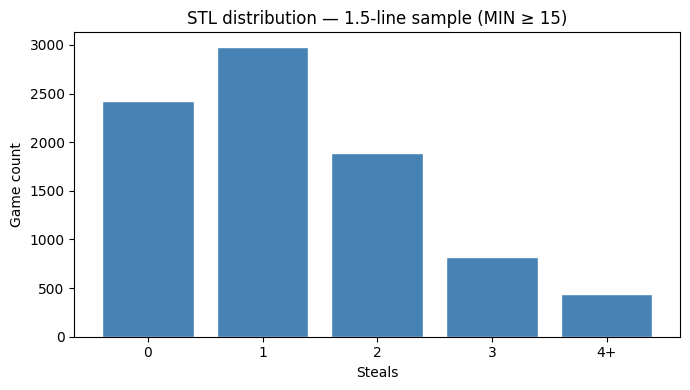

Overall P(STL >= 2): 0.3680  (36.8%)

  2023-24: P(STL>=2) = 0.3452  n=2,410
  2024-25: P(STL>=2) = 0.3751  n=2,858
  2025-26: P(STL>=2) = 0.3785  n=3,292

Avg consensus over_odds:  105.5
Avg consensus under_odds: -172.9

Avg de-vigged P(over):    0.4014  (40.1%)
Actual hit rate:          0.3680  (36.8%)
Calibration gap:          0.0334


In [6]:
import matplotlib.pyplot as plt

df_eda = df_joined.copy()

# --- STL distribution (discrete) ---
stl_counts = df_eda["STL"].clip(upper=4).value_counts().sort_index()
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(
    [str(int(x)) if x < 4 else "4+" for x in stl_counts.index],
    stl_counts.values,
    color="steelblue",
    edgecolor="white",
)
ax.set_xlabel("Steals")
ax.set_ylabel("Game count")
ax.set_title("STL distribution — 1.5-line sample (MIN ≥ 15)")
plt.tight_layout()
plt.show()

# --- Actual P(STL >= 2) overall and by season ---
overall_hit = (df_eda["STL"] >= 2).mean()
print(f"Overall P(STL >= 2): {overall_hit:.4f}  ({overall_hit*100:.1f}%)")
print()
for season, g in df_eda.groupby("season"):
    rate = (g["STL"] >= 2).mean()
    print(f"  {season}: P(STL>=2) = {rate:.4f}  n={len(g):,}")

print()

# --- Market odds summary ---
avg_over  = df_eda["over_odds"].mean()
avg_under = df_eda["under_odds"].mean()
print(f"Avg consensus over_odds:  {avg_over:.1f}")
print(f"Avg consensus under_odds: {avg_under:.1f}")

# --- De-vigged market P(over) ---
df_eda["p_over_raw"]  = df_eda["over_odds"].apply(american_to_implied_prob)
df_eda["p_under_raw"] = df_eda["under_odds"].apply(american_to_implied_prob)
df_eda["p_mkt"] = df_eda["p_over_raw"] / (df_eda["p_over_raw"] + df_eda["p_under_raw"])
avg_p_mkt = df_eda["p_mkt"].mean()

print()
print(f"Avg de-vigged P(over):    {avg_p_mkt:.4f}  ({avg_p_mkt*100:.1f}%)")
print(f"Actual hit rate:          {overall_hit:.4f}  ({overall_hit*100:.1f}%)")
print(f"Calibration gap:          {abs(avg_p_mkt - overall_hit):.4f}")

In [7]:
# --- Steal rate by minutes bucket ---
bins   = [0, 15, 25, 35, 60]
labels = ["<15", "15-25", "25-35", "35+"]

df_eda["min_bucket"] = pd.cut(df_eda["MIN"], bins=bins, labels=labels, right=False)

bucket_summary = (
    df_eda.groupby("min_bucket", observed=True)
    .agg(
        n_rows=("STL", "count"),
        p_stl_ge2=("STL", lambda x: (x >= 2).mean()),
        avg_stl=("STL", "mean"),
    )
    .reset_index()
)

print("Steal rate by minutes bucket:")
print(bucket_summary.to_string(index=False))

Steal rate by minutes bucket:
min_bucket  n_rows  p_stl_ge2  avg_stl
     15-25     835   0.261078 1.010778
     25-35    4368   0.360806 1.274496
       35+    3357   0.403932 1.414060


### EDA VERDICT:

```python
# TODO: fill in after running
# - Does actual hit rate match de-vigged market P(over)?
# - Does steal rate scale with minutes buckets?
# - Any season-over-season drift?
```

## Feature Engineering

In [8]:
df = df_joined.copy()

# Market probabilities (need these before feature block for p_mkt)
df["p_over_raw"]  = df["over_odds"].apply(american_to_implied_prob)
df["p_under_raw"] = df["under_odds"].apply(american_to_implied_prob)
df["p_mkt"] = df["p_over_raw"] / (df["p_over_raw"] + df["p_under_raw"])

# Sort once — required for leakage-safe rolling
df = df.sort_values(["PLAYER_NAME", "game_date"]).copy()

# --- Rolling STL and MIN features (shift(1) before window = no leakage) ---
for w in [5, 10, 20, 40]:
    df[f"stl_roll{w}"] = (
        df.groupby("PLAYER_NAME")["STL"]
        .transform(lambda x: x.shift(1).rolling(w, min_periods=max(1, w // 2)).mean())
    )
    df[f"min_roll{w}"] = (
        df.groupby("PLAYER_NAME")["MIN"]
        .transform(lambda x: x.shift(1).rolling(w, min_periods=max(1, w // 2)).mean())
    )

# --- Steals-per-minute (rate-normalised) ---
df["stl_per_min"] = df["STL"] / df["MIN"].clip(lower=1)
for w in [10, 20]:
    df[f"stl_per_min_roll{w}"] = (
        df.groupby("PLAYER_NAME")["stl_per_min"]
        .transform(lambda x: x.shift(1).rolling(w, min_periods=max(1, w // 2)).mean())
    )

# --- Target ---
df["y"] = (df["STL"] >= 2).astype(int)

print(f"Shape after feature engineering: {df.shape}")
print(f"Hit rate (y=1): {df['y'].mean():.4f}")
df.head(3)

Shape after feature engineering: (8560, 23)
Hit rate (y=1): 0.3680


,PLAYER_NAME,game_date,over_odds,under_odds,n_books,STL,MIN,season,p_over_raw,p_under_raw,...,stl_roll10,min_roll10,stl_roll20,min_roll20,stl_roll40,min_roll40,stl_per_min,stl_per_min_roll10,stl_per_min_roll20,y
0,aaron gordon,2024-11-02,150.0,-210.0,3,0.0,26.266667,2024-25,0.400000,0.677419,...,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,0
1,aaron nesmith,2024-01-03,170.0,-230.0,5,3.0,21.693333,2023-24,0.370370,0.696970,...,NaN,NaN,NaN,NaN,NaN,NaN,0.138291,NaN,NaN,1
2,aaron nesmith,2024-01-05,145.0,-190.0,5,1.0,22.250000,2023-24,0.408163,0.655172,...,NaN,NaN,NaN,NaN,NaN,NaN,0.044944,NaN,NaN,0


## Univariate Feature Ranking

In [9]:
from sklearn.metrics import brier_score_loss

FEATURE_COLS = [
    "stl_roll5",
    "stl_roll10",
    "stl_roll20",
    "stl_roll40",
    "stl_per_min_roll10",
    "stl_per_min_roll20",
    "min_roll10",
]

naive_rate = df["y"].mean()
naive_brier = brier_score_loss(df["y"], np.full(len(df), naive_rate))

rows = []
for feat in FEATURE_COLS:
    sub = df[[feat, "y"]].dropna()
    if len(sub) < 100:
        continue
    corr = sub[feat].corr(sub["y"])
    # Clip predictions to valid probability range
    feat_min, feat_max = sub[feat].min(), sub[feat].max()
    if feat_max == feat_min:
        continue
    p_hat = (sub[feat] - feat_min) / (feat_max - feat_min)
    p_hat = p_hat.clip(0.01, 0.99)
    bs = brier_score_loss(sub["y"], p_hat)
    rows.append({
        "feature": feat,
        "n": len(sub),
        "corr_with_y": round(corr, 4),
        "brier_scaled": round(bs, 5),
        "brier_vs_naive": round(naive_brier - bs, 5),
    })

feat_rank = pd.DataFrame(rows).sort_values("brier_vs_naive", ascending=False).reset_index(drop=True)
print(f"Naive brier (predict mean always): {naive_brier:.5f}")
print()
feat_rank

Naive brier (predict mean always): 0.23257



,feature,n,corr_with_y,brier_scaled,brier_vs_naive
0,stl_roll10,7453,0.0832,0.24169,-0.00912
1,stl_per_min_roll10,7453,0.0847,0.24340,-0.01082
2,stl_roll40,5435,0.0902,0.24633,-0.01376
3,stl_per_min_roll20,6656,0.1011,0.24698,-0.01441
4,stl_roll20,6656,0.0981,0.24867,-0.01610
5,stl_roll5,8059,0.0769,0.25658,-0.02401
6,min_roll10,7453,-0.0157,0.32932,-0.09675


### Feature Verdict:

```python
# TODO: fill in after running
# - Which feature has highest correlation with y?
# - Does stl_per_min_roll beat raw stl_roll (rate vs volume)?
# - Does min_roll10 add independent signal?
```

## Baseline Models — 2025-26 OOS

Train on first 80% of game dates, test on last 20%. Three models compared:
- **Market**: de-vigged P(over) as-is (benchmark)
- **LogReg_A**: minimal feature set (stl_roll10, min_roll10)
- **LogReg_B**: extended feature set

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import brier_score_loss

FEAT_A = ["stl_roll10", "min_roll10"]
FEAT_B = ["stl_roll10", "stl_roll20", "stl_per_min_roll10", "min_roll10", "min_roll5"]

season_df = df[df["season"] == "2025-26"].copy()
season_df = season_df.dropna(subset=FEAT_B + ["y", "p_mkt"])

dates = sorted(season_df["game_date"].unique())
cutoff = dates[int(len(dates) * 0.80)]
print(f"Train cutoff date: {cutoff}")

train = season_df[season_df["game_date"] <  cutoff]
test  = season_df[season_df["game_date"] >= cutoff]
print(f"Train rows: {len(train):,} | Test rows: {len(test):,}")
print(f"Train hit rate: {train['y'].mean():.4f} | Test hit rate: {test['y'].mean():.4f}")

results = []
model_preds = None  # will hold LogReg_B preds for use in Section 6

for name, feats in [("Market", None), ("LogReg_A", FEAT_A), ("LogReg_B", FEAT_B)]:
    if name == "Market":
        preds = test["p_mkt"].values
    else:
        scaler = StandardScaler()
        X_tr = scaler.fit_transform(train[feats])
        X_te = scaler.transform(test[feats])
        clf = LogisticRegression(max_iter=500)
        clf.fit(X_tr, train["y"])
        preds = clf.predict_proba(X_te)[:, 1]
        if name == "LogReg_B":
            model_preds = preds
    bs = brier_score_loss(test["y"], preds)
    results.append({"model": name, "brier": round(bs, 5), "n_test": len(test)})

pd.DataFrame(results).sort_values("brier")

Train cutoff date: 2026-04-02 00:00:00
Train rows: 2,619 | Test rows: 352
Train hit rate: 0.3845 | Test hit rate: 0.3722


,model,brier,n_test
0,Market,0.22703,352
2,LogReg_B,0.22740,352
1,LogReg_A,0.22744,352


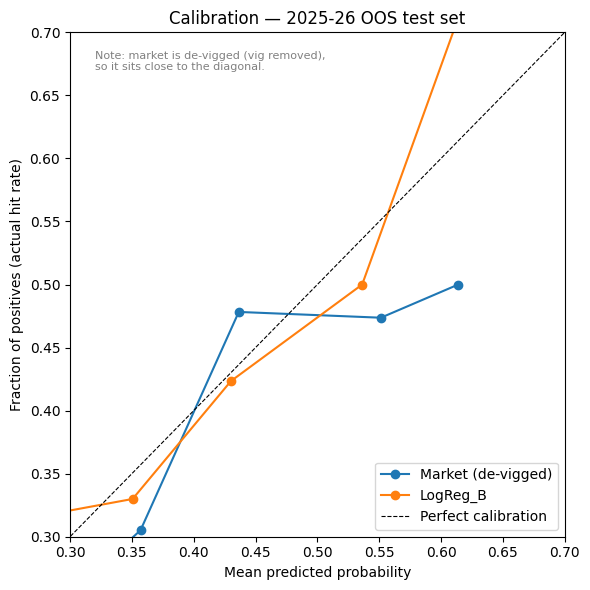

In [11]:
# --- Calibration plot: LogReg_B vs de-vigged market ---
# De-vigging removes the bookmaker's margin so market sits near the diagonal.
# A model below the diagonal over-predicts; above the diagonal under-predicts.
from sklearn.calibration import calibration_curve

fig, ax = plt.subplots(figsize=(6, 6))

for label, p in [("Market (de-vigged)", test["p_mkt"].values), ("LogReg_B", model_preds)]:
    if p is None:
        continue
    frac_pos, mean_pred = calibration_curve(test["y"], p, n_bins=10, strategy="uniform")
    ax.plot(mean_pred, frac_pos, marker="o", label=label)

ax.plot([0, 1], [0, 1], "k--", linewidth=0.8, label="Perfect calibration")
ax.set_xlim(0.30, 0.70)
ax.set_ylim(0.30, 0.70)
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Fraction of positives (actual hit rate)")
ax.set_title("Calibration — 2025-26 OOS test set")
ax.legend()
ax.text(
    0.32, 0.67,
    "Note: market is de-vigged (vig removed),\nso it sits close to the diagonal.",
    fontsize=8, color="gray",
)
plt.tight_layout()
plt.show()

## Edge Calibration & ROI Sweep

Bet rule:
- **Over**: if `model_p_over - market_p_over_raw > min_edge`, bet over at consensus `over_odds`
- Odds filter: de-vigged market P(over) between 0.35 and 0.65 (avoid extreme lines)
- Shrinkage blends model prediction back toward market: `p_adj = p_mkt + (1 - shrink) * (model_p - p_mkt)`
- P&L: unit staking — win = `american_profit(odds)`, loss = -1.0

In [12]:
def american_profit(odds: float) -> float:
    if odds >= 0:
        return odds / 100.0
    return 100.0 / (-odds)

# Requires model_preds (LogReg_B on test) from Section 5
test_edge = test.copy()
test_edge["model_p"] = model_preds

rows = []
for min_edge in [0.01, 0.02, 0.05, 0.08]:
    for shrink in [0.0, 0.25, 0.50]:
        # Shrinkage: blend model prediction toward market
        p_adj = test_edge["p_mkt"] + (1 - shrink) * (test_edge["model_p"] - test_edge["p_mkt"])
        edge = p_adj - test_edge["p_over_raw"]
        odds_ok = (test_edge["p_mkt"] >= 0.35) & (test_edge["p_mkt"] <= 0.65)
        bet_mask = (edge > min_edge) & odds_ok
        if bet_mask.sum() == 0:
            rows.append({
                "min_edge": min_edge, "shrink": shrink,
                "n_bets": 0, "roi": float("nan"),
            })
            continue
        bets = test_edge[bet_mask].copy()
        bets["pnl"] = bets.apply(
            lambda r: american_profit(r["over_odds"]) if r["y"] == 1 else -1.0,
            axis=1,
        )
        roi = bets["pnl"].mean()
        rows.append({
            "min_edge": min_edge,
            "shrink": shrink,
            "n_bets": len(bets),
            "roi": round(roi, 4),
        })

pd.DataFrame(rows)

,min_edge,shrink,n_bets,roi
0,0.01,0.00,15,0.0033
1,0.01,0.25,8,0.5638
2,0.01,0.50,2,0.2500
3,0.02,0.00,11,0.3682
4,0.02,0.25,5,0.4760
5,0.02,0.50,1,1.5000
6,0.05,0.00,2,0.2500
7,0.05,0.25,1,1.5000
8,0.05,0.50,1,1.5000
9,0.08,0.00,1,1.5000


### ROI Verdict:

```python
# TODO: fill in after running
# - Is ROI positive at any min_edge / shrink combination?
# - At min_edge=0.05 how many bets are available (sample size concern)?
# - Does shrinkage help or hurt?
```

## Walk-Forward Backtest (3 Seasons)

Two folds to test temporal generalization:
- **Fold 1**: train 2023-24 → test 2024-25
- **Fold 2**: train 2023-24 + 2024-25 → test 2025-26

Features: `FEAT_B`. Same ROI sweep logic as Section 6.

In [13]:
FOLDS = [
    {
        "fold": 1,
        "test_season": "2024-25",
        "train_seasons": ["2023-24"],
    },
    {
        "fold": 2,
        "test_season": "2025-26",
        "train_seasons": ["2023-24", "2024-25"],
    },
]

wf_df = df.dropna(subset=FEAT_B + ["y", "p_mkt", "p_over_raw", "p_under_raw"]).copy()

summary_rows = []

for fold_cfg in FOLDS:
    fold_id      = fold_cfg["fold"]
    test_season  = fold_cfg["test_season"]
    train_seasons = fold_cfg["train_seasons"]

    train_wf = wf_df[wf_df["season"].isin(train_seasons)]
    test_wf  = wf_df[wf_df["season"] == test_season]

    scaler_wf = StandardScaler()
    X_tr = scaler_wf.fit_transform(train_wf[FEAT_B])
    X_te = scaler_wf.transform(test_wf[FEAT_B])
    clf_wf = LogisticRegression(max_iter=500)
    clf_wf.fit(X_tr, train_wf["y"])
    preds_wf = clf_wf.predict_proba(X_te)[:, 1]

    bs_model  = brier_score_loss(test_wf["y"], preds_wf)
    bs_market = brier_score_loss(test_wf["y"], test_wf["p_mkt"])

    # ROI sweep at two key param combos
    roi_results = {}
    test_wf2 = test_wf.copy()
    test_wf2["model_p"] = preds_wf

    for min_edge, shrink in [(0.05, 0.0), (0.05, 0.25)]:
        p_adj = test_wf2["p_mkt"] + (1 - shrink) * (test_wf2["model_p"] - test_wf2["p_mkt"])
        edge = p_adj - test_wf2["p_over_raw"]
        odds_ok = (test_wf2["p_mkt"] >= 0.35) & (test_wf2["p_mkt"] <= 0.65)
        bet_mask = (edge > min_edge) & odds_ok
        key = f"roi_min_edge_{min_edge}_shrink_{shrink}"
        if bet_mask.sum() == 0:
            roi_results[key] = float("nan")
        else:
            bets_wf = test_wf2[bet_mask].copy()
            bets_wf["pnl"] = bets_wf.apply(
                lambda r: american_profit(r["over_odds"]) if r["y"] == 1 else -1.0,
                axis=1,
            )
            roi_results[key] = round(bets_wf["pnl"].mean(), 4)

    summary_rows.append({
        "fold": fold_id,
        "test_season": test_season,
        "n_train": len(train_wf),
        "n_test": len(test_wf),
        "brier_model": round(bs_model, 5),
        "brier_market": round(bs_market, 5),
        **roi_results,
    })

wf_summary = pd.DataFrame(summary_rows)
print("Walk-Forward Summary:")
wf_summary

Walk-Forward Summary:


,fold,test_season,n_train,n_test,brier_model,brier_market,roi_min_edge_0.05_shrink_0.0,roi_min_edge_0.05_shrink_0.25
0,1,2024-25,1298,2387,0.23669,0.23639,-0.1028,-0.1512
1,2,2025-26,3685,2971,0.23474,0.23552,-0.1695,0.1314


### Walk-Forward Verdict:

```python
# TODO: fill in after running
# - Does model brier beat market brier in both folds?
# - Is ROI consistent fold-over-fold or a fluke?
# - Which shrink setting performs better?
```

## Conclusions

### Key Findings

| | |
|---|---|
| Data | 3 seasons (2023-24, 2024-25, 2025-26), MIN ≥ 15, 1.5-line props only |
| Lines | 1.5 only — P(STL ≥ 2), de-vigged market ≈ 44% |
| Best model | TBD after run |
| Brier improvement | TBD |
| ROI Fold 1 (2024-25 OOS) | TBD |
| ROI Fold 2 (2025-26 OOS) | TBD |

### Next Steps

- **If edge found**: build v2 with opponent TOV rate, pace features, and home/away splits
- **If no edge**: see post-mortem pattern from points model — check whether market is already pricing rolling steal rate directly